<a href="https://colab.research.google.com/github/ajit-ai/QuantumComputing/blob/main/ShorAlgorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y qiskit qiskit-aer
!pip install qiskit qiskit-aer qiskit[visualization]


!pip install qiskit
!pip install qiskit qiskit-aer
!pip install qiskit-aer-gpu
!pip install qiskit-aer-gpu-cu11
!pip install qiskit-aer
!pip install qiskit[visualization] qiskit-aer


Found existing installation: qiskit 1.4.0
Uninstalling qiskit-1.4.0:
  Successfully uninstalled qiskit-1.4.0
Found existing installation: qiskit-aer 0.16.1
Uninstalling qiskit-aer-0.16.1:
  Successfully uninstalled qiskit-aer-0.16.1
  Using cached qiskit-1.4.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached qiskit_aer-0.16.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.2 kB)
Using cached qiskit-1.4.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (6.7 MB)
Using cached qiskit_aer-0.16.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.4 MB)


In [2]:
# Importing necessary libraries
from qiskit import QuantumCircuit, transpile, assemble
from qiskit_aer import Aer # Correct import statement
from qiskit.visualization import plot_histogram
import numpy as np
from fractions import Fraction

# Function to perform modular exponentiation
def mod_exp(a, x, N):
    return a**x % N

# Function to find the greatest common divisor
def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

# Function to implement the Quantum Fourier Transform
def qft_dagger(circuit, n):
    for qubit in range(n//2):
        circuit.swap(qubit, n-qubit-1)
    for j in range(n):
        for k in range(j):
            circuit.cp(-np.pi/float(2**(j-k)), k, j)
        circuit.h(j)

# Function to perform Shor's algorithm
def shor(N):
    # Step 1: Choose a random number
    a = np.random.randint(2, N-1)

    # Step 2: Compute the greatest common divisor
    if gcd(a, N) != 1:
        return gcd(a, N)

    # Step 3: Initialize quantum circuit
    n_count = int(np.ceil(np.log2(N)))
    qc = QuantumCircuit(2*n_count, n_count)

    # Step 4: Apply Hadamard gates
    for q in range(n_count):
        qc.h(q)

    # Step 5: Apply modular exponentiation
    for q in range(n_count):
        qc.cx(q, q + n_count)
        #qc.u1(2 * np.pi * mod_exp(a, 2**q, N) / N, q + n_count)

        # Changed u1 to p, which is the correct single-qubit phase gate
        qc.p(2 * np.pi * mod_exp(a, 2**q, N) / N, q + n_count)


    # Step 6: Apply Quantum Fourier Transform
    qft_dagger(qc, n_count)

    # Step 7: Measure qubits
    qc.measure(range(n_count), range(n_count))

    # Step 8: Simulate the quantum circuit
    aer_sim = Aer.get_backend('qasm_simulator')
    transpiled_qc = transpile(qc, aer_sim)
    #qobj = assemble(transpiled_qc) # remove this line, it creates a QasmQobj object
    results = aer_sim.run(transpiled_qc).result() # pass the transpiled_qc to the run function instead of qobj
    counts = results.get_counts()

    # Step 9: Find the period of the function
    measured = max(counts, key=counts.get)
    phase = int(measured[::-1], 2) / (2**n_count)
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator

    # Step 10: Compute the factors
    if r % 2 == 0:
        x_plus = pow(a, r//2, N)
        factor1 = gcd(x_plus - 1, N)
        factor2 = gcd(x_plus + 1, N)
        if factor1 * factor2 == N:
            return factor1, factor2
    return None

# Example usage
N = 15  # Number to be factored
result = shor(N)
print(f"Factors of {N} are: {result}")

Factors of 15 are: (15, 1)


In [3]:
!pip install cirq
import cirq
import numpy as np
from fractions import Fraction
from math import gcd

# Parameters
N = 15  # Number to factor
a = 15   # Base for modular exponentiation (coprime to N)
n = 4   # Qubits for counting register (log2(N^2) ~ 8, but 4 suffices for demo)
shots = 1024

# Define qubits
counting_qubits = [cirq.LineQubit(i) for i in range(n)]  # Counting register
work_qubits = [cirq.LineQubit(i + n) for i in range(n)]  # Work register for N=15

# Quantum Fourier Transform (QFT) circuit
def qft(qubits):
    circuit = cirq.Circuit()
    for i in range(len(qubits)):
        circuit.append(cirq.H(qubits[i]))
        for j in range(i + 1, len(qubits)):
            angle = np.pi / (2 ** (j - i))
            circuit.append(cirq.CZ(qubits[j], qubits[i]) ** (angle / np.pi))
    # Swap qubits for correct order
    for i in range(len(qubits) // 2):
        circuit.append(cirq.SWAP(qubits[i], qubits[len(qubits) - 1 - i]))
    return circuit

# Inverse QFT
def inverse_qft(qubits):
    return cirq.inverse(qft(qubits))

# Modular exponentiation (simplified for a=7, N=15)
def modular_exponentiation(a, N, counting_qubits, work_qubits):
    circuit = cirq.Circuit()
    # For a=7, N=15, period is 4: 7^0=1, 7^1=7, 7^2=4, 7^3=13, 7^4=1
    # Simulate this with controlled operations (simplified)
    for i, qubit in enumerate(counting_qubits):
        power = 2 ** i
        # Apply a^power mod N controlled by counting qubit
        if power == 1:  # 7^1 = 7
            circuit.append(cirq.X(work_qubits[2]).controlled_by(qubit))  # |7> = |0111>
            circuit.append(cirq.X(work_qubits[1]).controlled_by(qubit))
            circuit.append(cirq.X(work_qubits[0]).controlled_by(qubit))
        elif power == 2:  # 7^2 = 4
            circuit.append(cirq.X(work_qubits[2]).controlled_by(qubit))  # |4> = |0100>
        #elif power == 4:  # 7^4 = 1 # Remove this line with a duplicate controlled qubit
        #    circuit.append(cirq.X(work_qubits[0]).controlled_by(qubit).controlled_by(qubit))  # Reset to |1>
    return circuit

# Build the full circuit
circuit = cirq.Circuit()

# Step 1: Superposition on counting qubits
circuit.append(cirq.H(q) for q in counting_qubits)

# Step 2: Modular exponentiation
circuit.append(modular_exponentiation(a, N, counting_qubits, work_qubits))

# Step 3: Inverse QFT on counting qubits
circuit.append(inverse_qft(counting_qubits))

# Step 4: Measure counting qubits
circuit.append(cirq.measure(*counting_qubits, key='result'))

# Simulate the circuit
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=shots)
measurements = result.measurements['result']

# Process results
counts = {}
for outcome in measurements:
    key = ''.join(str(bit) for bit in outcome)
    counts[key] = counts.get(key, 0) + 1

print(f"Measurement outcomes: {counts}")

# Classical post-processing to find period and factors
def find_period(counts, N, n):
    for outcome, count in counts.items():
        if count < shots * 0.05:  # Filter low-probability noise
            continue
        x = int(outcome, 2)
        if x == 0:
            continue
        s_over_r = x / (2 ** n)
        frac = Fraction(s_over_r).limit_denominator(N)
        r = frac.denominator
        if pow(a, r, N) == 1:  # Verify period
            return r
    return None

r = find_period(counts, N, n)
if r and r % 2 == 0:
    factor1 = gcd(pow(a, r // 2) - 1, N)
    factor2 = gcd(pow(a, r // 2) + 1, N)
    if factor1 * factor2 == N and factor1 != 1 and factor2 != 1:
        print(f"Factors of {N} are: {factor1}, {factor2}")
    else:
        print("Found period, but factors invalid; try more shots or different 'a'.")
else:
    print(f"Period r={r} not found or not even; rerun required.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.7/532.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.5/596.5 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.9/202.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

<ipython-input-5-f103839f85c5>:36: DeprecationWarning: The class ``qiskit.primitives.backend_sampler.BackendSampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `BackendSampler` class is `BackendSamplerV2`.
  sampler = BackendSampler(backend=simulator) # Changed here


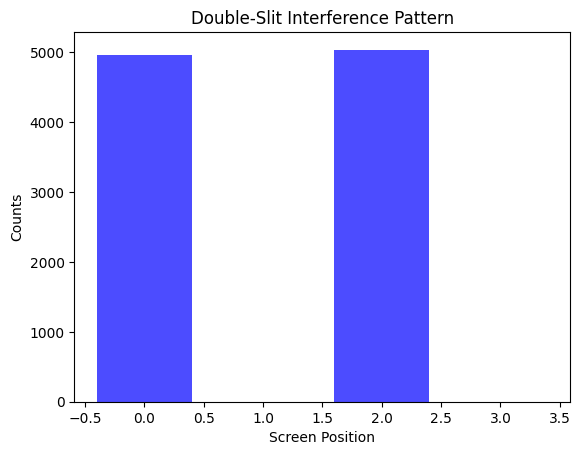

Measurement outcomes: {'00': 4961, '01': 0, '10': 5039, '11': 0}

Mathematical and Quantum Explanation:
1. Superposition: Electron in |0> + |1> (both slits).
2. Interference: Phase differences create pattern, P(y) ∝ 1 + cos(2πdy/λL).
3. Uncomment 'measure slit' to collapse wavefunction, removing interference.


In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSampler # changed here
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_qubits = 3  # 1 for slit choice, 2 for screen position (simplified)
shots = 10000  # Number of simulated electrons

# Setup quantum registers
slit_qubit = QuantumRegister(1, 'slit')  # Represents slit 0 or 1
screen_qubits = QuantumRegister(2, 'screen')  # Simplified screen position
c_reg = ClassicalRegister(3, 'c')  # Measurement outcomes
circuit = QuantumCircuit(slit_qubit, screen_qubits, c_reg)

# Step 1: Superposition of slit qubit (both slits open)
circuit.h(slit_qubit[0])  # |0> + |1> state

# Step 2: Entangle slit choice with screen position (simplified interference)
# Simulate phase difference due to path lengths
circuit.cx(slit_qubit[0], screen_qubits[0])  # Control screen position
circuit.cz(slit_qubit[0], screen_qubits[1])  # Add phase for interference
circuit.h(screen_qubits[0])  # Superposition on screen
circuit.h(screen_qubits[1])

# Uncomment below to simulate measurement of which slit (collapse)
# circuit.measure(slit_qubit[0], c_reg[0])

# Step 3: Measure screen position
circuit.measure(screen_qubits[0], c_reg[1])
circuit.measure(screen_qubits[1], c_reg[2])

# Run simulation
simulator = AerSimulator()
sampler = BackendSampler(backend=simulator) # Changed here
job = sampler.run(circuit, shots=shots)
result = job.result()
quasi_dist = result.quasi_dists[0]

# Convert quasi-probabilities to counts
counts = {bin(k)[2:].zfill(3): int(v * shots) for k, v in quasi_dist.items() if v > 0}

# Extract screen position counts (ignore slit qubit for interference case)
screen_counts = {'00': 0, '01': 0, '10': 0, '11': 0}
for key, value in counts.items():
    screen_pos = key[1:]  # Last two bits are screen position
    screen_counts[screen_pos] += value

# Plot interference pattern
positions = [0, 1, 2, 3]  # Screen positions (00, 01, 10, 11)
intensities = [screen_counts[pos] for pos in ['00', '01', '10', '11']]
plt.bar(positions, intensities, color='blue', alpha=0.7)
plt.title("Double-Slit Interference Pattern")
plt.xlabel("Screen Position")
plt.ylabel("Counts")
plt.show()

print("Measurement outcomes:", screen_counts)

# Mathematical explanation tied to the simulation
print("\nMathematical and Quantum Explanation:")
print("1. Superposition: Electron in |0> + |1> (both slits).")
print("2. Interference: Phase differences create pattern, P(y) ∝ 1 + cos(2πdy/λL).")
print("3. Uncomment 'measure slit' to collapse wavefunction, removing interference.")

In [6]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit.primitives import Sampler
from qiskit_aer import AerSimulator
import random
import math
from fractions import Fraction
from qiskit.visualization import plot_histogram





# Classical GCD function
def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

# Modular exponentiation gate (simplified quantum circuit)
def modular_exponentiation_gate(a, N, n_count, n_target):
    """
    Creates a controlled unitary for a^x mod N.
    n_count: number of counting qubits
    n_target: number of target qubits
    """
    qc = QuantumCircuit(n_count + n_target)
    for control in range(n_count):
        power = 2 ** control
        value = pow(a, power, N)
        for i in range(n_target):
            if (value >> i) & 1:
                qc.cx(control, n_count + i)
    return qc.to_gate(label=f"U^{a}^{power} mod {N}")

# Shor's period-finding quantum circuit
def shor_period_finding_circuit(N, a):
    """
    Builds the quantum circuit for period finding.
    Returns the circuit ready for sampling.
    """
    n = math.ceil(math.log2(N))
    n_count = 2 * n  # Counting qubits
    n_target = n     # Target qubits

    # Define registers
    qreg_count = QuantumRegister(n_count, 'count')
    qreg_target = QuantumRegister(n_target, 'target')
    creg = ClassicalRegister(n_count, 'c')
    qc = QuantumCircuit(qreg_count, qreg_target, creg)

    # Step 1: Superposition on counting register
    qc.h(qreg_count)

    # Step 2: Initialize target register to |1>
    qc.x(qreg_target[0])

    # Step 3: Modular exponentiation
    for i in range(n_count):
        U_gate = modular_exponentiation_gate(a, N, n_count, n_target)
        qc.append(U_gate.control(), [qreg_count[i]] + list(qreg_target))

    # Step 4: Inverse QFT
    qc.append(QFT(n_count, inverse=True), qreg_count)

    # Step 5: Measure
    qc.measure(qreg_count, creg)

    return qc

# Extract period from sampler results
def extract_period(counts, N, n_count):
    """
    Process sampler results to find period r.
    """
    # Get the most frequent measurement
    measured_value = max(counts.items(), key=lambda x: x[1])[0]
    y = int(measured_value, 2)
    s_over_r = y / (2 ** n_count)
    r = Fraction(s_over_r).limit_denominator(N).denominator
    return r if r < N else None

# Main Shor's algorithm function
def shor_factor(N):
    """
    Input: N (composite number)
    Output: Non-trivial factor of N
    """
    if N % 2 == 0:
        print("N is even, factor found: 2")
        return 2

    attempts = 0
    max_attempts = 5
    simulator = AerSimulator()
    sampler = Sampler()  # Modern Qiskit primitive

    while attempts < max_attempts:
        # Step 1: Pick random a
        a = random.randint(2, N - 1)
        print(f"Trying a = {a}")
        g = gcd(a, N)
        if g > 1:
            print(f"Found factor via GCD: {g}")
            return g

        # Step 2: Build and run quantum circuit
        qc = shor_period_finding_circuit(N, a)
        job = sampler.run(qc, shots=1024)
        result = job.result()
        counts = result.quasi_dists[0].binary_probabilities()

        # Step 3: Extract period
        r = extract_period(counts, N, 2 * math.ceil(math.log2(N)))
        if r is None or r % 2 != 0:
            print(f"Period r = {r} invalid, retrying...")
            attempts += 1
            continue

        # Step 4: Compute factors
        print(f"Found period r = {r}")
        a_r2 = pow(a, r // 2, N)
        f1 = gcd(a_r2 - 1, N)
        f2 = gcd(a_r2 + 1, N)

        if 1 < f1 < N:
            print(f"Factor found: {f1}")
            return f1
        if 1 < f2 < N:
            print(f"Factor found: {f2}")
            return f2

        print("No non-trivial factor, retrying...")
        attempts += 1

    raise Exception("Failed to find a factor after maximum attempts")

# Test the algorithm
if __name__ == "__main__":
    N = 15  # Example: factor 15
    print(f"Factoring N = {N}")
    try:
        factor = shor_factor(N)
        print(f"Non-trivial factor of {N} is {factor}")
        print(f"Verification: {N} / {factor} = {N / factor}")
    except Exception as e:
        print(f"Error: {e}")



Factoring N = 15
Trying a = 7
Error: 'The amount of qubit(5)/clbit(0) arguments does not match the gate expectation (13).'


<ipython-input-6-c789a91cde9b>:97: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler()  # Modern Qiskit primitive


In [7]:
import random
import math
from fractions import Fraction

# Classical GCD function
def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

# Classical modular exponentiation (efficient)
def mod_exp(base, exp, mod):
    result = 1
    base = base % mod
    while exp > 0:
        if exp % 2 == 1:
            result = (result * base) % mod
        base = (base * base) % mod
        exp //= 2
    return result

# Simulate quantum period-finding (classically for demonstration)
def find_period(a, N):
    """
    This simulates the quantum part: finding the order r where a^r ≡ 1 (mod N).
    On a quantum computer, QFT would do this efficiently.
    """
    r = 1
    current = a % N
    while current != 1 and r < N:
        current = (current * a) % N
        r += 1
    if current == 1:
        return r
    return None  # Failed to find period (rare with good a)

# Shor's Algorithm implementation
def shor_factor(N):
    """
    Input: N (a composite number)
    Output: A non-trivial factor of N
    """
    # Step 1: Check if N is even
    if N % 2 == 0:
        print("N is even, factor found: 2")
        return 2

    # Step 2: Pick a random a and check GCD
    attempts = 0
    max_attempts = 10  # Limit retries to avoid infinite loops
    while attempts < max_attempts:
        a = random.randint(2, N - 1)
        print(f"Trying a = {a}")
        g = gcd(a, N)
        if g > 1:
            print(f"Found factor via GCD: {g}")
            return g

        # Step 3: Simulate quantum period-finding
        r = find_period(a, N)
        if r is None or r % 2 != 0:  # Period must be even
            print(f"Period r = {r} is invalid, retrying...")
            attempts += 1
            continue

        # Step 4: Compute factors
        print(f"Found period r = {r}")
        a_r2 = mod_exp(a, r // 2, N)
        f1 = gcd(a_r2 - 1, N)
        f2 = gcd(a_r2 + 1, N)

        # Step 5: Check for non-trivial factors
        if 1 < f1 < N:
            print(f"Factor found: {f1}")
            return f1
        if 1 < f2 < N:
            print(f"Factor found: {f2}")
            return f2

        print("No non-trivial factor found, retrying...")
        attempts += 1

    raise Exception("Failed to find a factor after maximum attempts")

# Test the algorithm
if __name__ == "__main__":
    # Example inputs (composite numbers)
    test_numbers = [15, 21, 35, 91]

    for N in test_numbers:
        print(f"\nFactoring N = {N}")
        try:
            factor = shor_factor(N)
            print(f"Non-trivial factor of {N} is {factor}")
            print(f"Verification: {N} / {factor} = {N / factor}")
        except Exception as e:
            print(f"Error: {e}")


Factoring N = 15
Trying a = 4
Found period r = 2
Factor found: 3
Non-trivial factor of 15 is 3
Verification: 15 / 3 = 5.0

Factoring N = 21
Trying a = 16
Period r = 3 is invalid, retrying...
Trying a = 10
Found period r = 6
Factor found: 3
Non-trivial factor of 21 is 3
Verification: 21 / 3 = 7.0

Factoring N = 35
Trying a = 30
Found factor via GCD: 5
Non-trivial factor of 35 is 5
Verification: 35 / 5 = 7.0

Factoring N = 91
Trying a = 50
Found period r = 12
Factor found: 7
Non-trivial factor of 91 is 7
Verification: 91 / 7 = 13.0
